In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Churn_Modelling.csv')
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)



In [4]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:\n", df.describe())

Shape: (10000, 11)

Data Types:
 CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Basic Stats:
         CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0

#***EDA***

/tmp/ipykernel_13415/1686748137.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
/tmp/ipykernel_13415/1686748137.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Retained', 'Churned'])


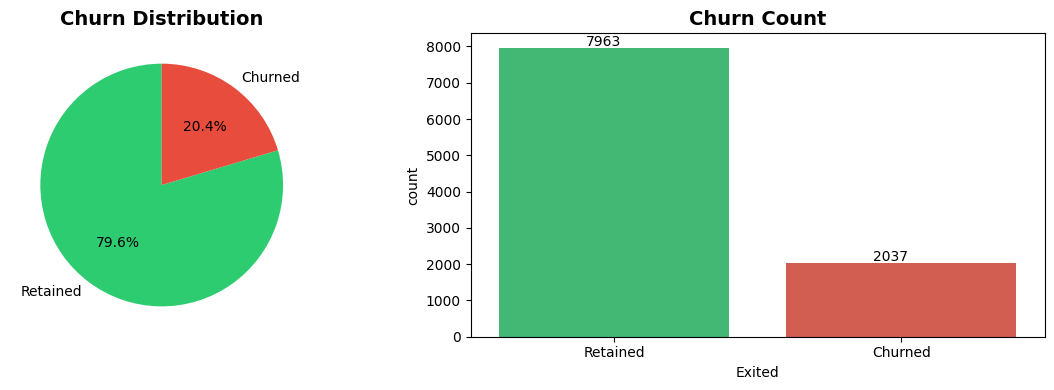

In [7]:
# ── 1. Class Imbalance ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Exited'].value_counts()
axes[0].pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

sns.countplot(x='Exited', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 50))
plt.tight_layout()
plt.show()





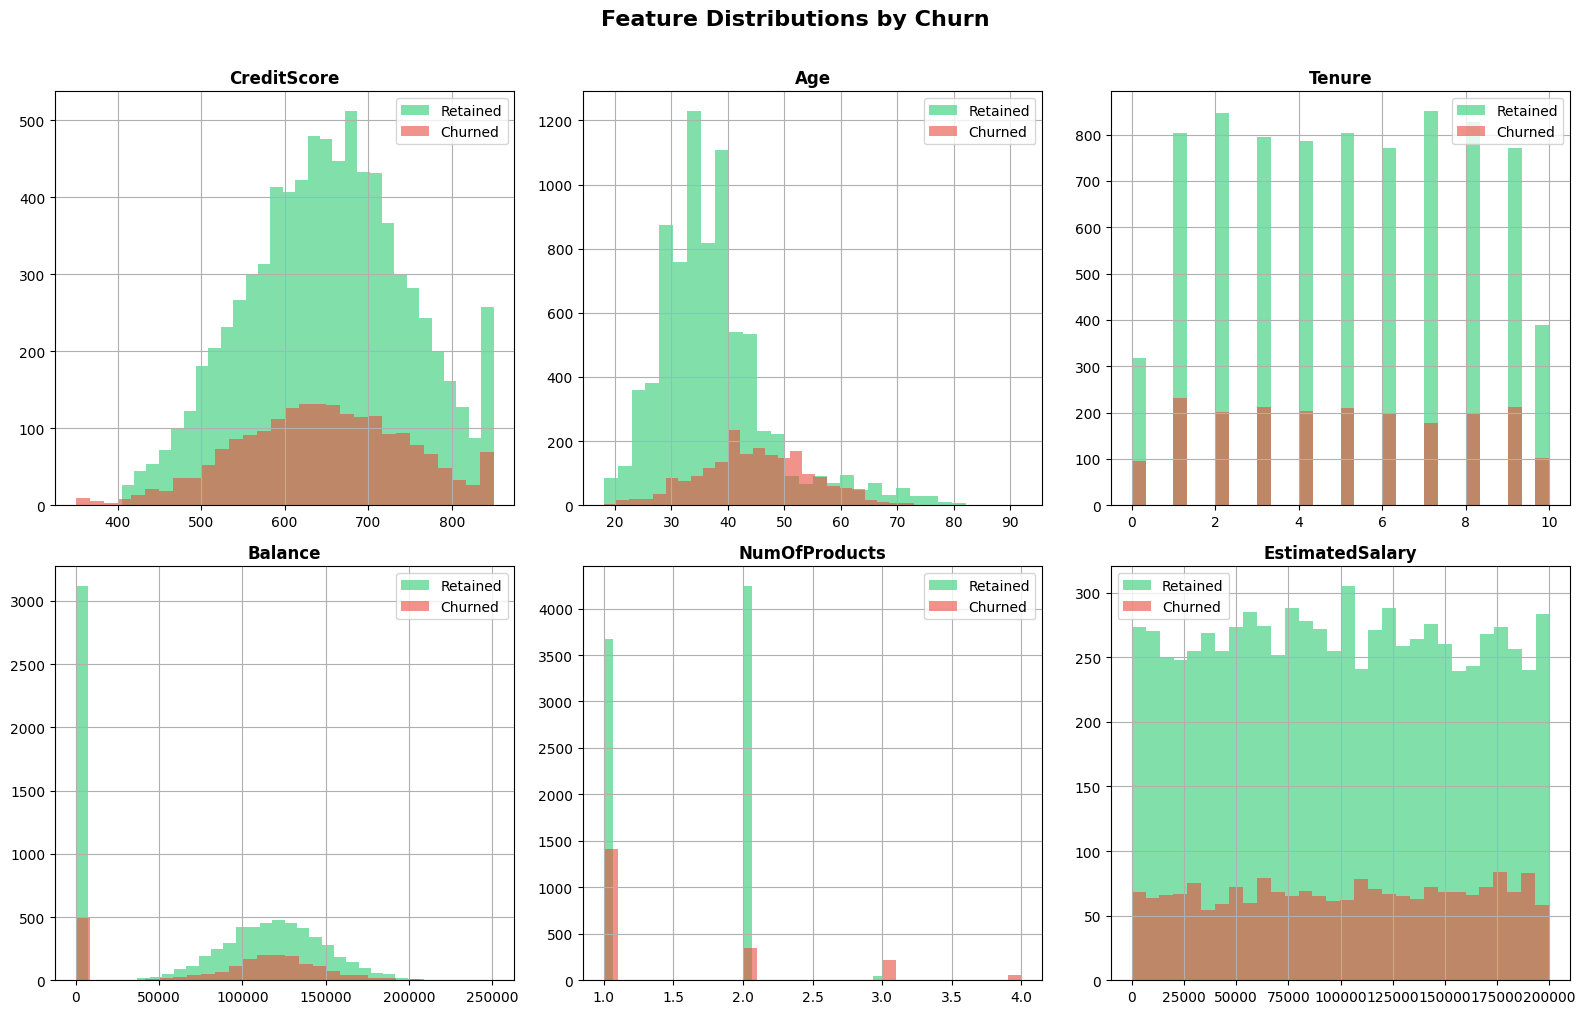

In [9]:
# ── 2. Numerical Feature Distributions by Churn ────────
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
            'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df[df['Exited'] == 0][col].hist(ax=axes[i], alpha=0.6, color='#2ecc71',
                                     bins=30, label='Retained')
    df[df['Exited'] == 1][col].hist(ax=axes[i], alpha=0.6, color='#e74c3c',
                                     bins=30, label='Churned')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend()
plt.suptitle('Feature Distributions by Churn', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


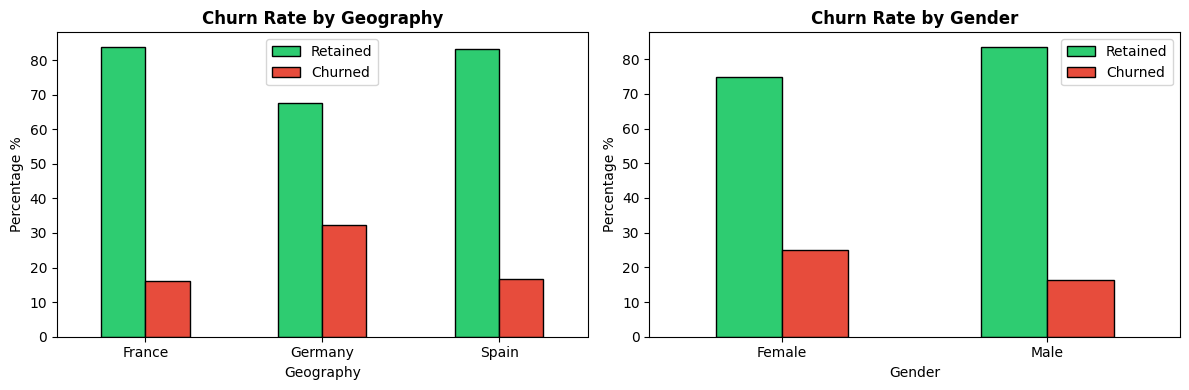

In [10]:
# ── 3. Categorical Features vs Churn ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['Geography', 'Gender']):
    ct = pd.crosstab(df[col], df['Exited'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_title(f'Churn Rate by {col}', fontweight='bold')
    ax.set_ylabel('Percentage %')
    ax.legend(['Retained', 'Churned'])
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


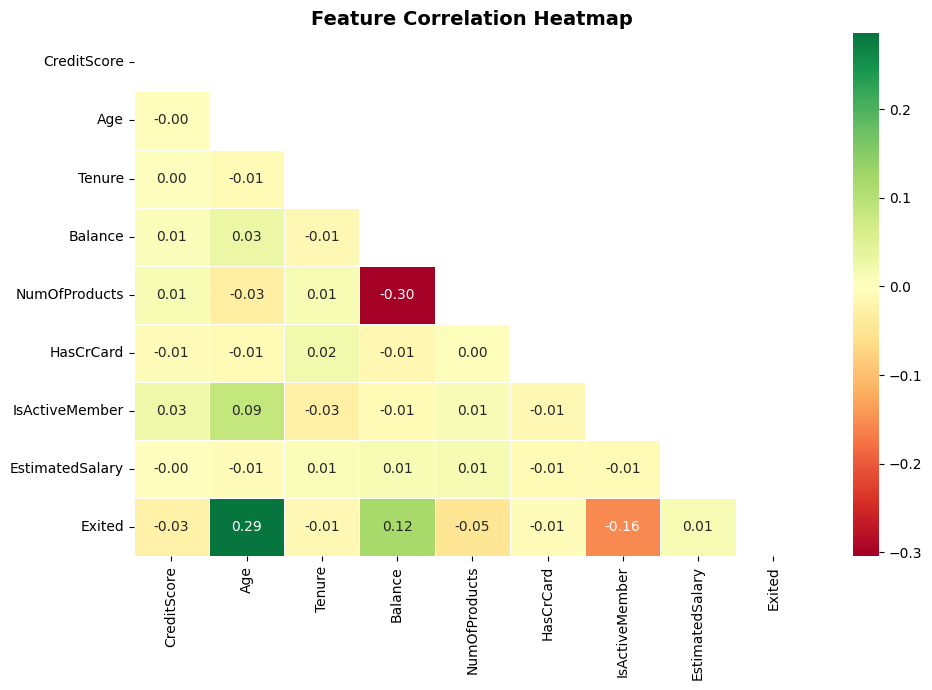

In [11]:
# ── 4. Correlation Heatmap ─────────────────────────────
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#***Preprocessing***

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf


df_model = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)


X = df_model.drop(columns=['Exited'])
y = df_model['Exited'].values



In [14]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify keeps 20% churn in both splits
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Churn % in train: {y_train.mean()*100:.1f}%")
print(f"Churn % in test : {y_test.mean()*100:.1f}%")




Train size: (8000, 11), Test size: (2000, 11)
Churn % in train: 20.4%
Churn % in test : 20.3%


In [16]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)



In [17]:
#Handle Class Imbalance via class_weight
# 20% churn = imbalanced. We tell the model to penalize missing a churn more.
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\nClass weights: {class_weight_dict}")


Class weights: {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}


#***ANN model***

In [18]:
pip install tensorflow

In [20]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── 1. Build Model ─────────────────────────────────────
tf.random.set_seed(42)

model = Sequential([
    # Input + first hidden layer
    Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]),
    BatchNormalization(),
    Dropout(0.3),

    # Second hidden layer
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Third hidden layer
    Dense(16, activation='relu'),
    Dropout(0.2),

    # Output — sigmoid for binary classification
    Dense(1, activation='sigmoid')
])

model.summary()






/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 192 (768.00 B)

In [23]:
# ── 2. Compile ─────────────────────────────────────────
model.compile(
    optimizer="Adam",
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]  # track AUC too
)


In [24]:
# ── 3. Callbacks ───────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_auc',       # stop when val AUC stops improving
        patience=15,
        restore_best_weights=True,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',      # halve LR when val_loss plateaus
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

In [25]:
# ── 4. Train ───────────────────────────────────────────
history = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,   # imbalance fix applied here
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5791 - auc: 0.6707 - loss: 0.6768 - val_accuracy: 0.7881 - val_auc: 0.7989 - val_loss: 0.5299 - learning_rate: 0.0010
Epoch 2/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6888 - auc: 0.7506 - loss: 0.5972 - val_accuracy: 0.7706 - val_auc: 0.8278 - val_loss: 0.4998 - learning_rate: 0.0010
Epoch 3/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7095 - auc: 0.7726 - loss: 0.5758 - val_accuracy: 0.7663 - val_auc: 0.8406 - val_loss: 0.4840 - learning_rate: 0.0010
Epoch 4/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7261 - auc: 0.7991 - loss: 0.5471 - val_accuracy: 0.7775 - val_auc: 0.8437 - val_loss: 0.4813 - learning_rate: 0.0010
Epoch 5/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7430 - auc: 0.8174 - loss: 0.5233 - val_accuracy: 0.7919 - val_auc: 0.8505 - val_loss: 0.4594 - learning_rate: 0.0010
Epoch 6/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7458 -

In [26]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve)

# ── 1. Predict ─────────────────────────────────────────
y_prob = model.predict(X_test_scaled).flatten()        # probabilities
y_pred = (y_prob >= 0.5).astype(int)               # FIX: correct thresholding


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [27]:
# ── 2. Classification Report ───────────────────────────
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))



Classification Report:
              precision    recall  f1-score   support

    Retained       0.93      0.80      0.86      1593
     Churned       0.49      0.77      0.60       407

    accuracy                           0.79      2000
   macro avg       0.71      0.78      0.73      2000
weighted avg       0.84      0.79      0.81      2000



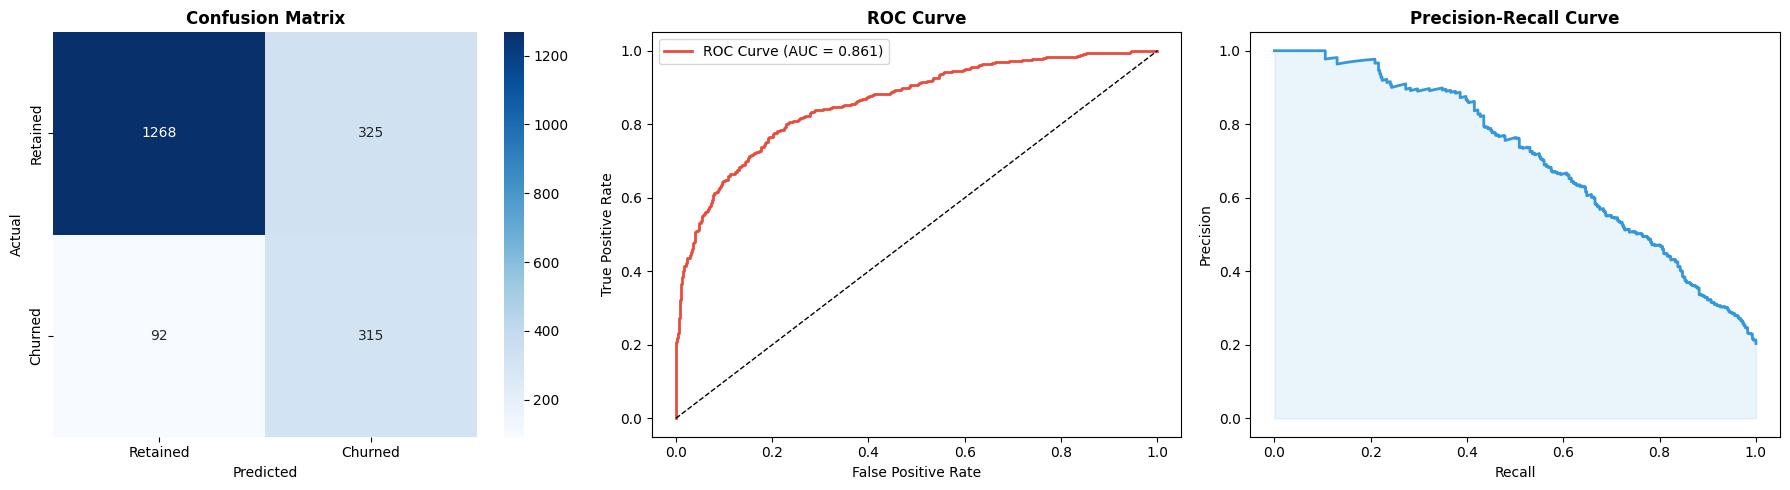

In [35]:
# ── 3. Confusion Matrix ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ── 4. ROC Curve ───────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

# ── 5. Precision-Recall Curve ──────────────────────────
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
axes[2].plot(recall, precision, color='#3498db', lw=2)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].fill_between(recall, precision, alpha=0.1, color='#3498db')

plt.tight_layout()
plt.show()


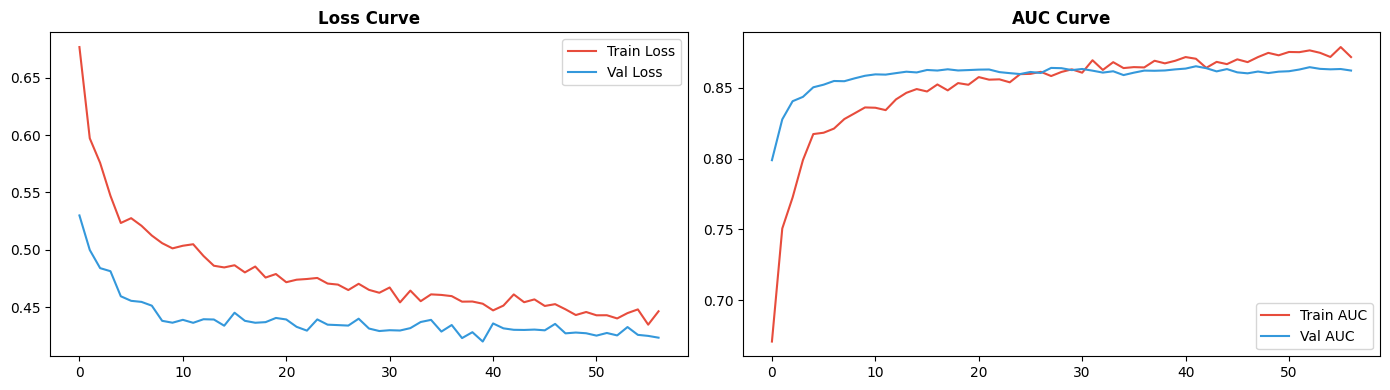

In [36]:
# ── 6. Training History ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#3498db')
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC', color='#e74c3c')
axes[1].plot(history.history['val_auc'], label='Val AUC', color='#3498db')
axes[1].set_title('AUC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [37]:
# ── 7. Find Optimal Threshold ──────────────────────────
f1_scores = []
from sklearn.metrics import f1_score
for t in thresholds:
    f1_scores.append(f1_score(y_test, (y_prob >= t).astype(int)))

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
print(f"\nOptimal Threshold: {best_thresh:.3f}  →  Best F1: {best_f1:.3f}")
print(f"Default (0.5) F1:  {f1_score(y_test, y_pred):.3f}")


Optimal Threshold: 0.650  →  Best F1: 0.638
Default (0.5) F1:  0.602


In [38]:
import pickle

# ── Save the Keras model ───────────────────────────────
model.save('churn_model.keras')

# ── Save the scaler ────────────────────────────────────
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# ── Save the optimal threshold ─────────────────────────
with open('threshold.pkl', 'wb') as f:
    pickle.dump(best_thresh, f)

# ── Save feature column names ──────────────────────────
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("Saved: churn_model.keras, scaler.pkl, threshold.pkl, feature_cols.pkl")
print("Feature columns:", X.columns.tolist())

Saved: churn_model.keras, scaler.pkl, threshold.pkl, feature_cols.pkl
Feature columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
